In [1]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

# Loading Data

In [2]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [4]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [ ]:
# Fit the label encoder to the classes (industry names)

label_encoder = LabelEncoder()
label_encoder.fit(df_train['industry'])

print(f"Number of unique industries: {len(label_encoder.classes_)}")
print(f"\nIndustry classes:")

for idx, industry in enumerate(label_encoder.classes_):
    print(f"{idx}: {industry}")

Number of unique industries: 25

Industry classes:
0: Automobiles & Components
1: Banks
2: Capital Goods
3: Commercial & Professional Services
4: Consumer Discretionary Distribution & Retail
5: Consumer Durables & Apparel
6: Consumer Services
7: Consumer Staples Distribution & Retail
8: Energy
9: Equity Real Estate Investment Trusts (REITs)
10: Financial Services
11: Food, Beverage & Tobacco
12: Health Care Equipment & Services
13: Household & Personal Products
14: Insurance
15: Materials
16: Media & Entertainment
17: Pharmaceuticals, Biotechnology & Life Sciences
18: Real Estate Management & Development
19: Semiconductors & Semiconductor Equipment
20: Software & Services
21: Technology Hardware & Equipment
22: Telecommunication Services
23: Transportation
24: Utilities


In [18]:
y_train = label_encoder.transform(df_train['industry'])
y_val = label_encoder.transform(df_val['industry'])

# Check if all validation classes are in training set
train_classes = set(df_train['industry'].unique())
val_classes = set(df_val['industry'].unique())

print(f"All validation classes in training: {val_classes.issubset(train_classes)}")
print(f"\nTraining labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")

All validation classes in training: True

Training labels shape: (28535,)
Validation labels shape: (3171,)


# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

In [9]:
# Analyze class distribution
class_counts = df_train['industry'].value_counts()

print("Class Distribution:")
print(class_counts)
print(f"\nMean: {class_counts.mean():.1f}")
print(f"Std: {class_counts.std():.1f}")
print(f"Min: {class_counts.min()}")
print(f"Max: {class_counts.max()}")

Class Distribution:
industry
Materials                                         7604
Capital Goods                                     2805
Pharmaceuticals, Biotechnology & Life Sciences    1742
Financial Services                                1740
Technology Hardware & Equipment                   1390
Software & Services                               1384
Energy                                            1174
Consumer Durables & Apparel                       1037
Food, Beverage & Tobacco                           956
Health Care Equipment & Services                   911
Banks                                              874
Media & Entertainment                              827
Real Estate Management & Development               825
Commercial & Professional Services                 726
Consumer Services                                  591
Consumer Discretionary Distribution & Retail       591
Automobiles & Components                           572
Semiconductors & Semiconductor Equip

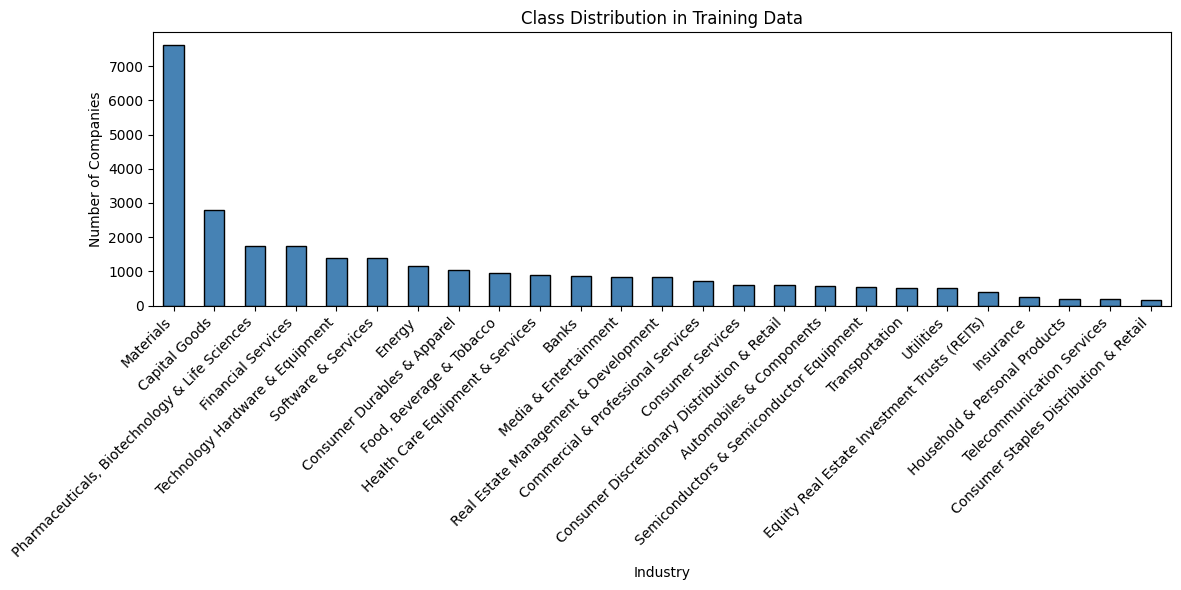

In [10]:
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.title('Class Distribution in Training Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### PCA - Dimensionality reduction and visualization

In [11]:
# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print(f"Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Total: {pca.explained_variance_ratio_.sum():.4f}")

Explained variance ratio:
PC1: 0.1930
PC2: 0.0610
Total: 0.2540


# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [15]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_val)

# Metrics
acc_lr = accuracy_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr, average='weighted')

print("Logistic Regression:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

Logistic Regression:
Accuracy: 0.7720
F1 Score: 0.7663


In [16]:
# Train k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_val)

# Metrics
acc_knn = accuracy_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn, average='weighted')

print("k-NN (k=5):")
print(f"Accuracy: {acc_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")

k-NN (k=5):
Accuracy: 0.7531
F1 Score: 0.7495


In [19]:
print("\nModel Comparison:")
print(f"{'Model':<20} {'Accuracy':<12} {'F1 Score':<12}")
print("-" * 44)
print(f"{'Logistic Regression':<20} {acc_lr:<12.4f} {f1_lr:<12.4f}")
print(f"{'k-NN (k=5)':<20} {acc_knn:<12.4f} {f1_knn:<12.4f}")


Model Comparison:
Model                Accuracy     F1 Score    
--------------------------------------------
Logistic Regression  0.7720       0.7663      
k-NN (k=5)           0.7531       0.7495      


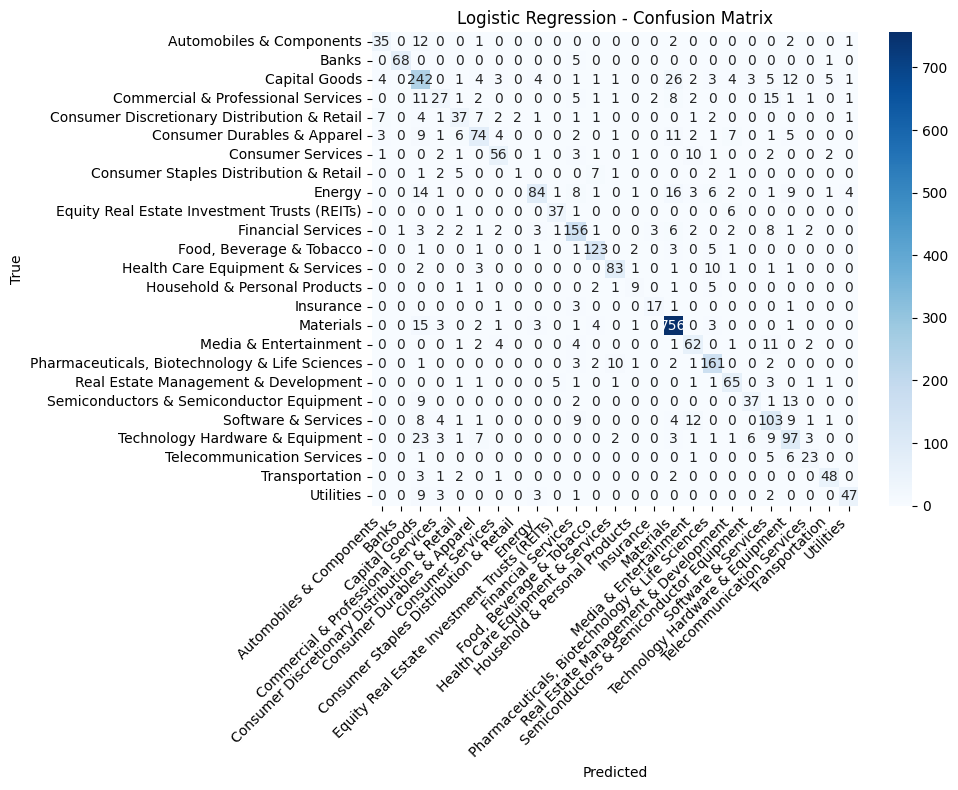

In [20]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_val, y_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

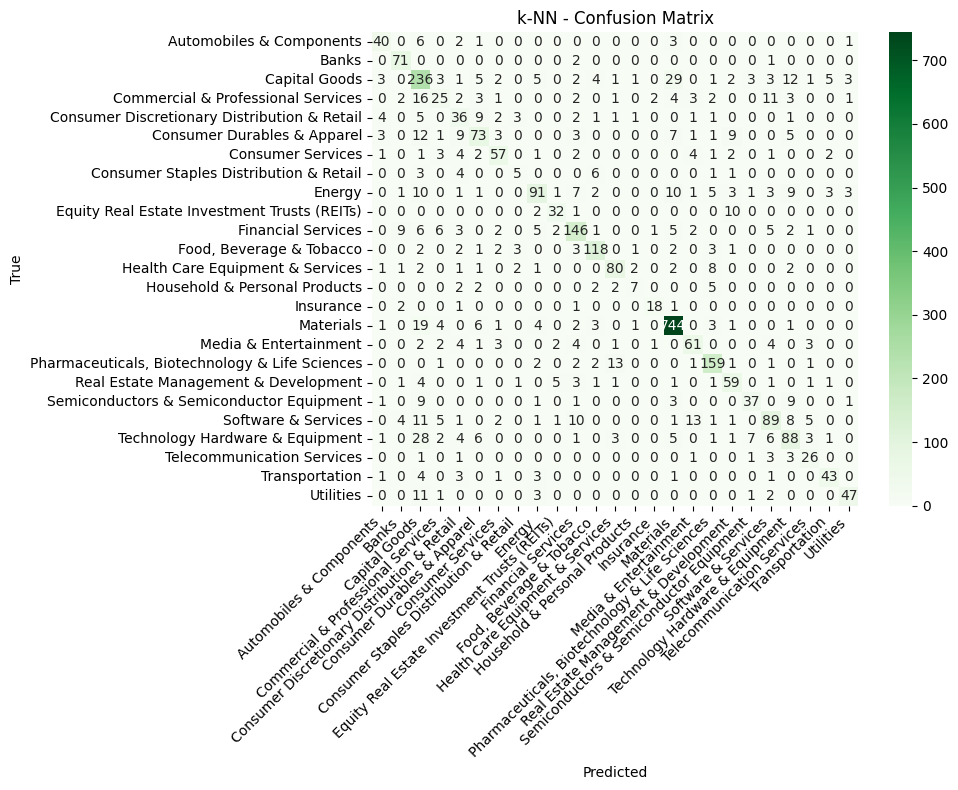

In [21]:
# Confusion matrix for k-NN
cm_knn = confusion_matrix(y_val, y_pred_knn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('k-NN - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report

print("Logistic Regression - Classification Report:")
print(classification_report(y_val, y_pred_lr, target_names=label_encoder.classes_))

print("k-NN - Classification Report:")
print(classification_report(y_val, y_pred_knn, target_names=label_encoder.classes_))

Logistic Regression - Classification Report:
                                                precision    recall  f1-score   support

                      Automobiles & Components       0.70      0.66      0.68        53
                                         Banks       0.99      0.92      0.95        74
                                 Capital Goods       0.66      0.75      0.70       322
            Commercial & Professional Services       0.54      0.35      0.42        78
  Consumer Discretionary Distribution & Retail       0.61      0.55      0.58        67
                   Consumer Durables & Apparel       0.69      0.58      0.63       127
                             Consumer Services       0.76      0.69      0.72        81
        Consumer Staples Distribution & Retail       0.33      0.05      0.09        20
                                        Energy       0.84      0.55      0.67       152
  Equity Real Estate Investment Trusts (REITs)       0.84      0.82      0

In [24]:
# Analyze if both models make the same errors
lr_errors = y_val != y_pred_lr
knn_errors = y_val != y_pred_knn
common_errors = lr_errors & knn_errors

print("Error Analysis:")
print(f"LR errors: {lr_errors.sum()} ({lr_errors.sum()/len(y_val)*100:.1f}%)")
print(f"k-NN errors: {knn_errors.sum()} ({knn_errors.sum()/len(y_val)*100:.1f}%)")
print(f"Common errors: {common_errors.sum()} ({common_errors.sum()/len(y_val)*100:.1f}%)")
print(f"\nBoth models misclassify the same examples: {common_errors.sum()/max(lr_errors.sum(), 1)*100:.1f}% of LR errors")

Error Analysis:
LR errors: 723 (22.8%)
k-NN errors: 783 (24.7%)
Common errors: 535 (16.9%)

Both models misclassify the same examples: 74.0% of LR errors


In [25]:
from sklearn.metrics import precision_recall_fscore_support

# Get per-class metrics for Logistic Regression
precision_lr, recall_lr, f1_lr_class, support_val = precision_recall_fscore_support(
    y_val, y_pred_lr, labels=range(len(label_encoder.classes_))
)

# Get training class distribution
train_support = np.bincount(y_train)

# Create DataFrame for analysis
performance_df = pd.DataFrame({
    'Industry': label_encoder.classes_,
    'Train_Samples': train_support,
    'Val_Samples': support_val,
    'LR_F1': f1_lr_class,
})

performance_df = performance_df.sort_values('LR_F1', ascending=False)

print("Top 5 Best Performing Industries:")
print(performance_df.head(5).to_string(index=False))
print("\nTop 5 Worst Performing Industries:")
print(performance_df.tail(5).to_string(index=False))

Top 5 Best Performing Industries:
                                      Industry  Train_Samples  Val_Samples    LR_F1
                                         Banks            874           74 0.951049
                                     Materials           7604          790 0.925903
                      Food, Beverage & Tobacco            956          138 0.872340
Pharmaceuticals, Biotechnology & Life Sciences           1742          183 0.838542
  Equity Real Estate Investment Trusts (REITs)            387           45 0.831461

Top 5 Worst Performing Industries:
                                    Industry  Train_Samples  Val_Samples    LR_F1
             Technology Hardware & Equipment           1390          157 0.615873
Consumer Discretionary Distribution & Retail            591           67 0.578125
               Household & Personal Products            206           20 0.500000
          Commercial & Professional Services            726           78 0.421875
      Consumer S

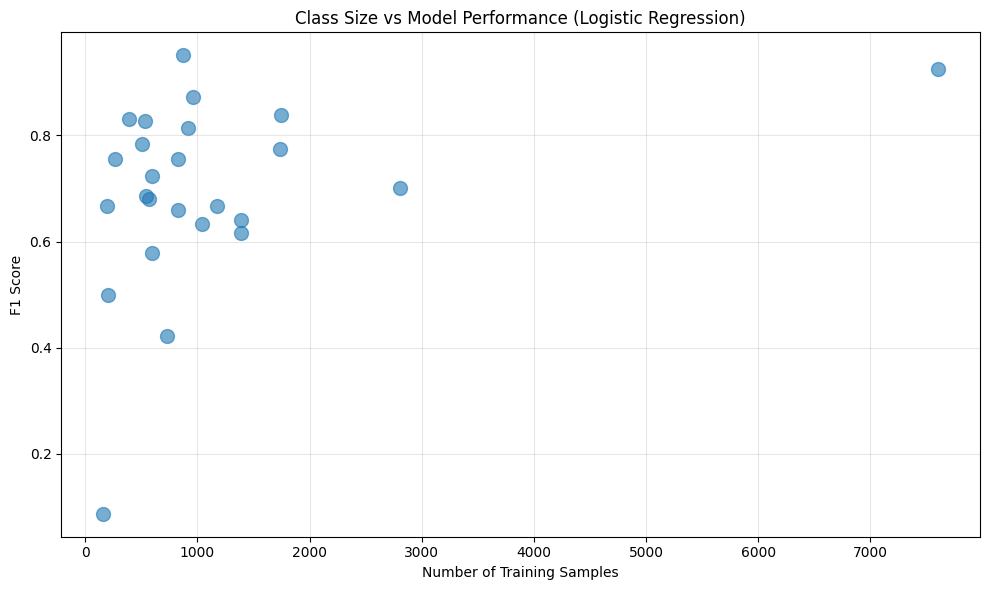

In [27]:
# Visualize relationship between class size and performance
plt.figure(figsize=(10, 6))
plt.scatter(performance_df['Train_Samples'], performance_df['LR_F1'], s=100, alpha=0.6)

plt.xlabel('Number of Training Samples')
plt.ylabel('F1 Score')
plt.title('Class Size vs Model Performance (Logistic Regression)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis Summary:

**Model Performance:**
- Logistic Regression: 77.2% accuracy, 0.77 F1 score
- k-NN: 75.3% accuracy, 0.75 F1 score
- Logistic Regression performs slightly better overall

**How Metrics Work:**
- **Accuracy**: Proportion of correct predictions (correct/total)
- **F1 Score**: Harmonic mean of precision and recall, better for imbalanced data
- For a 25-class problem, 77% is good performance

**Key Findings:**

1. **Class Imbalance Effect**: 
   - Underrepresented classes (e.g., Consumer Staples Distribution & Retail with only 20 validation samples) have much lower F1 scores
   - Materials has the most samples (~7500) and highest F1 (0.93)

2. **Best Identified Industries**:
   - Banks (0.95 F1)
   - Materials (0.93 F1)
   - Food, Beverage & Tobacco (0.87 F1)

3. **Most Confused Industries**:
   - Consumer Staples Distribution & Retail (0.09 F1) - very small class
   - Commercial & Professional Services (0.42 F1)
   - Household & Personal Products (0.50 F1)

4. **Error Overlap**:
   - Both models struggle with similar examples, suggesting these are inherently difficult cases
   - Similar industries (e.g., different tech sectors) are often confused with each other

5. **Industry Similarity**:
   - Technology-related industries (Software, Hardware, Semiconductors) show confusion
   - Retail/Distribution categories overlap
   - Real estate categories (REITs vs Management) have some confusion

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [ ]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

In [28]:
# Load financial data
df_financials = pd.read_pickle("data/df_financials_train.pkl")

print(f"Financial data shape: {df_financials.shape}")
print(f"\nFinancial columns:")
print(df_financials.columns.tolist())
df_financials.head()

Financial data shape: (29561, 5)

Financial columns:
['id', 'country_code', 'net_profit_margin', 'ebitda_margin', 'asset_turnover']


,id,country_code,net_profit_margin,ebitda_margin,asset_turnover
0,0,CHN,0.303422,NaN,0.025426
1,1,CHN,-0.141921,-0.130371,0.266802
2,2,CHN,-1.333215,NaN,0.317023
3,3,CHN,-0.258595,NaN,0.352064
4,4,CHN,0.183619,NaN,0.963834


In [29]:
# Merge financial data with train and validation sets
df_train_with_fin = df_train.merge(df_financials, on='id', how='left')
df_val_with_fin = df_val.merge(df_financials, on='id', how='left')

print(f"Train set with financials: {df_train_with_fin.shape}")
print(f"Validation set with financials: {df_val_with_fin.shape}")
print(f"\nMissing values:")
print(df_train_with_fin[['net_profit_margin', 'ebitda_margin', 'asset_turnover']].isnull().sum())

Train set with financials: (28690, 7)
Validation set with financials: (3179, 7)

Missing values:
net_profit_margin     3062
ebitda_margin        19426
asset_turnover        3294
dtype: int64


In [31]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Select financial columns
fin_cols = ['net_profit_margin', 'ebitda_margin', 'asset_turnover']

# Extract financial features
X_train_fin = df_train_with_fin[fin_cols].copy()
X_val_fin = df_val_with_fin[fin_cols].copy()

# Replace infinite values with NaN
X_train_fin = X_train_fin.replace([np.inf, -np.inf], np.nan)
X_val_fin = X_val_fin.replace([np.inf, -np.inf], np.nan)

# Clip extreme outliers using IQR method
for col in fin_cols:
    Q1 = X_train_fin[col].quantile(0.25)
    Q3 = X_train_fin[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    X_train_fin[col] = X_train_fin[col].clip(lower, upper)
    X_val_fin[col] = X_val_fin[col].clip(lower, upper)

# Convert to numpy arrays
X_train_fin = X_train_fin.values
X_val_fin = X_val_fin.values

# Handle remaining missing values (fill with median)
imputer = SimpleImputer(strategy='median')
X_train_fin = imputer.fit_transform(X_train_fin)
X_val_fin = imputer.transform(X_val_fin)

# Standardize
scaler = StandardScaler()
X_train_fin = scaler.fit_transform(X_train_fin)
X_val_fin = scaler.transform(X_val_fin)

print(f"Financial features processed successfully!")
print(f"Shape: {X_train_fin.shape}")
print(f"No NaN: {not np.isnan(X_train_fin).any()}")
print(f"No Inf: {not np.isinf(X_train_fin).any()}")

Financial features processed successfully!
Shape: (28690, 3)
No NaN: True
No Inf: True


In [32]:
# Combine embeddings with financial features
X_train_combined = np.hstack([X_train, X_train_fin])
X_val_combined = np.hstack([X_val, X_val_fin])

print(f"Original embedding shape: {X_train.shape}")
print(f"Combined features shape: {X_train_combined.shape}")
print(f"Added {X_train_fin.shape[1]} financial features")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 28535 and the array at index 1 has size 28690